In [9]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from gymnasium.wrappers import RecordVideo

In [7]:
NUM_EPISODES = 100000
EPSILON = np.linspace(0.9, 0.1, NUM_EPISODES)
DISCOUNT = 0.9
ALPHA = 0.1

In [ ]:
def train(env):
    obs_dim = env.observation_space.n
    act_dim = env.action_space.n

    Q = np.zeros((obs_dim, act_dim))
    reward_history = []

    for i, eps in enumerate(EPSILON):
        done = False
        total_reward = 0
        state, info = env.reset()
        action = np.argmax(Q[state]) if np.random.rand() > eps else env.action_space.sample()

        while not done:
            next_state, reward, terminated, truncated, info = env.step(action)
            next_action = np.argmax(Q[next_state]) if np.random.rand() > eps else env.action_space.sample()
            
            Q[state, action] += ALPHA * (
                reward + DISCOUNT * max(Q[next_state]) - Q[state, action]
            )

            total_reward += reward

            state = next_state
            action = next_action
            done = terminated or truncated

        reward_history.append(total_reward)

        # if not (i + 1) % 1000:
        #     print(f"Episode: {i+1}/{NUM_EPISODES}, Total reward: {total_reward}")

    return Q, reward_history

# Stochastic Environment

In [ ]:
env = gym.make("CliffWalking-v1", is_slippery=True)
Q, reward_history = train(env)

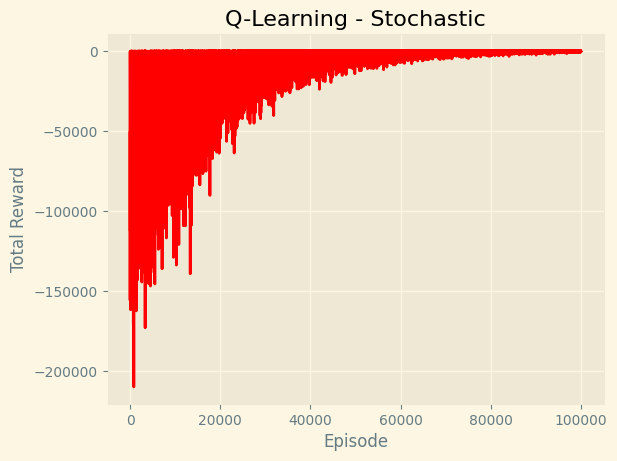

In [ ]:
reward_history = np.load("../experiments/ql_stochastic_rh.npy")
plt.style.use("Solarize_Light2")
plt.plot(reward_history, color="red")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-Learning - Stochastic")
plt.show()

In [ ]:
np.save('../results/logs/ql_stochastic_rh.npy', reward_history)
np.save('../results/checkpoints/ql_stochastic_q.npy', Q)

# Deterministic Environment

In [ ]:
env = gym.make("CliffWalking-v1", is_slippery=False)
Q, reward_history = train(env)

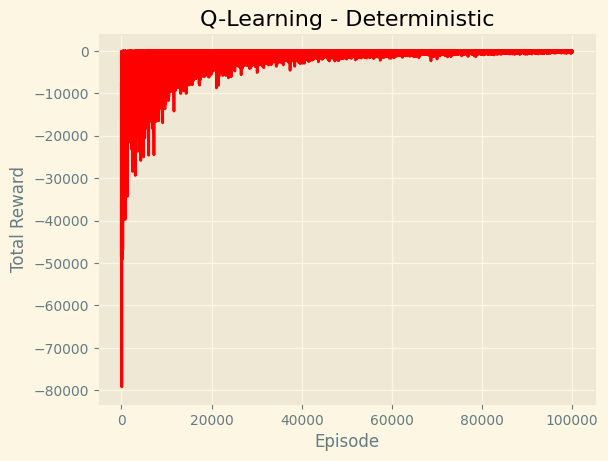

In [ ]:
reward_history = np.load("../experiments/ql_deterministic_rh.npy")
plt.style.use("Solarize_Light2")
plt.plot(reward_history, color="red")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-Learning - Deterministic")
plt.show()

In [ ]:
np.save('../results/logs/ql_deterministic_rh.npy', reward_history)
np.save('../results/checkpoints/ql_deterministic_q.npy', Q)

# Evaluation

In [13]:
Q = np.load("../results/checkpoints/ql_stochastic_q.npy")

In [ ]:
eval_env = gym.make("CliffWalking-v1", is_slippery=True, render_mode="rgb_array")
eval_env = RecordVideo(eval_env, video_folder="../results/videos", name_prefix="ql_stochastic", episode_trigger=lambda x: True)

observation, info = eval_env.reset(seed=42)
terminated = False
while not terminated:
    action = np.argmax(Q[observation])
    observation, reward, terminated, truncated, info = eval_env.step(action)

    if truncated:
        observation, info = eval_env.reset()

eval_env.close()

# Q-Learning vs SARSA vs Monte Carlo

In [2]:
def running_mean_cumsum(x, N=1000):
    cumsum = np.cumsum(np.insert(x, 0, 0)) 
    return (cumsum[N:] - cumsum[:-N]) / float(N)

In [ ]:
ql_rewards = running_mean_cumsum(np.load("../results/logs/ql_stochastic_rh.npy"))
sa_rewards = running_mean_cumsum(np.load("../results/logs/sarsa_stochastic_rh.npy"))
mc_rewards = running_mean_cumsum(np.load("../results/logs/mc_stochastic_rh.npy"))

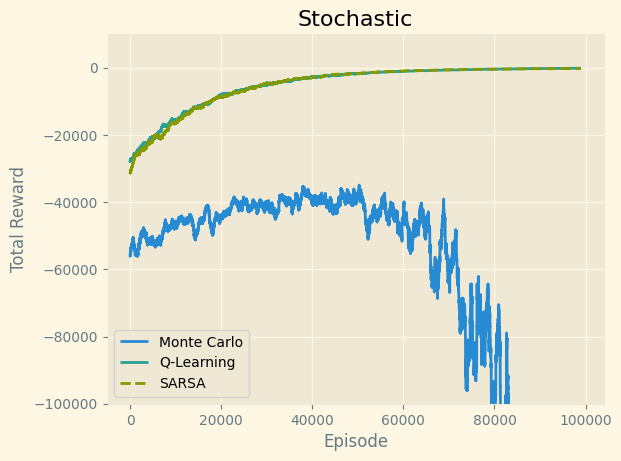

In [8]:
plt.style.use("Solarize_Light2")
plt.plot(mc_rewards, label="Monte Carlo")
plt.plot(ql_rewards, label="Q-Learning")
plt.plot(sa_rewards, label="SARSA", linestyle="--")
plt.ylim(-100000, 10000)
plt.legend()
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Stochastic")
plt.show()

In [ ]:
ql_rewards = running_mean_cumsum(np.load("../results/logs/ql_deterministic_rh.npy"))
sa_rewards = running_mean_cumsum(np.load("../results/logs/sarsa_deterministic_rh.npy"))
mc_rewards = running_mean_cumsum(np.load("../results/logs/mc_deterministic_rh.npy"))

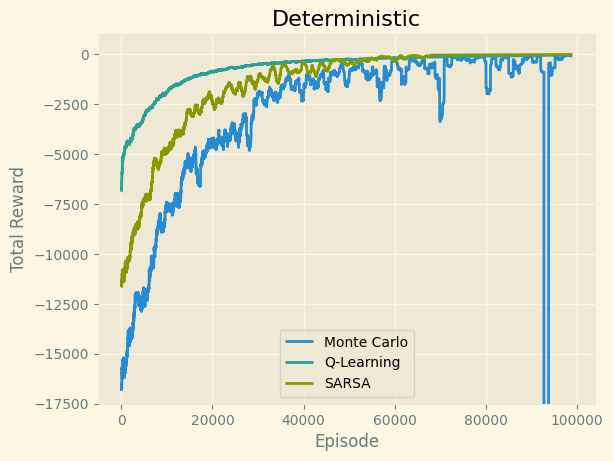

In [63]:
plt.style.use("Solarize_Light2")
plt.plot(mc_rewards, label="Monte Carlo")
plt.plot(ql_rewards, label="Q-Learning")
plt.plot(sa_rewards, label="SARSA")
plt.ylim(-17500, 1000)
plt.legend()
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Deterministic")
plt.show()

## Agent behavior on Q-Learning and SARSA

The plots below show that the agent using SARSA avoids the cliff as much as possible, while the agent using Q-Learning chooses the most optimal although risky to reach the goal state. This is expected as SARSA's update rule considers the state-action value of the actual action it took in the trajectory. Due to the epsilon randomness, the agent falls off the cliff in the initial runs and the agent using SARSA is traumatised by this experience. This makes the agent quite pessimistic and it avoids the cliff region in the future. Now, the agent using Q-Learning however, updates its state-action value using the best outcome of the next state, and cliff has the highest best outcome since it is closer to the goal. It is very optimitisic in this regard, making it a risky adventurer.

In [6]:
def plot_value_heatmap(Q):
    V = np.max(Q, axis=1).reshape(4, 12)

    plt.style.use("Solarize_Light2")
    plt.grid(False)
    im = plt.imshow(V, cmap='magma', interpolation='nearest')
    plt.colorbar(im)
    plt.title("CliffWalking State Values")
    plt.show()

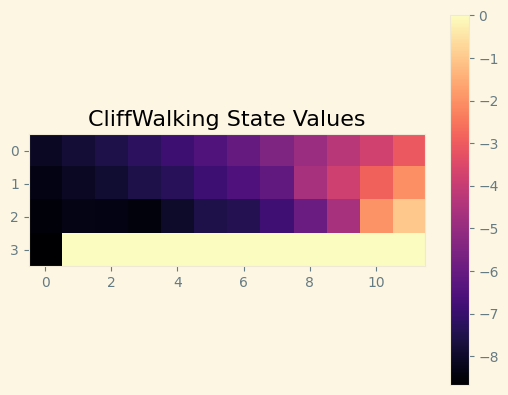

In [ ]:
sarsa_Q = np.load("../results/checkpoints/sarsa_deterministic_q.npy")
plot_value_heatmap(sarsa_Q)

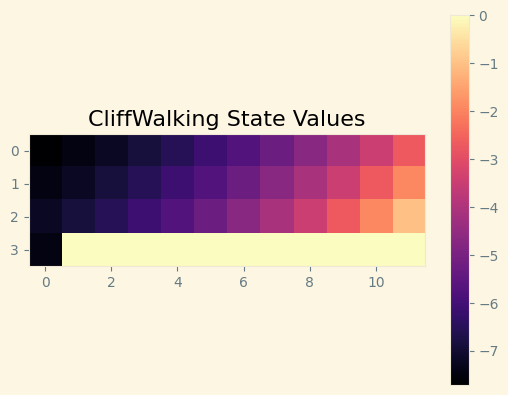

In [ ]:
ql_Q = np.load("../results/checkpoints/ql_deterministic_q.npy")
plot_value_heatmap(ql_Q)